# 통신사 고객 이탈 예측 모델링

## 프로젝트 목적

고객의 통화·요금·단말기·인구통계 정보를 활용해 이탈(`Churn`) 여부를 예측한다.
특히 **Retention(이탈 방어 활동) 변수 포함 여부가 모델 성능에 미치는 영향**을 공정하게 비교한다.

- `with_retention`: Retention 변수를 포함한 피처 세트
- `without_retention`: Retention 변수를 제외한 피처 세트
- 각 피처 세트는 제공된 **train 파일로만 학습**하고, **validation 파일로만 검증**한다.
- 동일한 네 가지 분류 모델을 적용해 ROC-AUC, Accuracy, Precision, Recall, F1-score를 비교한다.

In [1]:
# 1. 라이브러리와 프로젝트 경로 설정
# %pip install pandas numpy scikit-learn matplotlib seaborn joblib
from pathlib import Path
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import joblib
from sklearn.ensemble import HistGradientBoostingClassifier, RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import RobustScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.inspection import permutation_importance

warnings.filterwarnings("ignore")
RANDOM_STATE = 42
TARGET = "Churn"


# PyCharm의 실행 위치가 프로젝트 루트이거나 notebooks 폴더여도 data/interim을 찾도록 설정한다.
current_path = Path.cwd().resolve()
candidate_roots = [current_path, *current_path.parents]
PROJECT_ROOT = next(
    (path for path in candidate_roots if (path / "data" / "interim").is_dir()),
    None,
)
if PROJECT_ROOT is None:
    raise FileNotFoundError(
        "data/interim 폴더를 찾지 못했습니다. "
        "PyCharm에서 프로젝트 루트를 열었는지 확인하세요."
    )

DATA_DIR = PROJECT_ROOT / "data" / "interim"
OUTPUT_DIR = PROJECT_ROOT / "artifacts" / "modeling"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("프로젝트 루트:", PROJECT_ROOT)
print("데이터 폴더:", DATA_DIR)
print("결과 저장 폴더:", OUTPUT_DIR)

프로젝트 루트: C:\SKN_AI\skn-2nd-project-churnpred
데이터 폴더: C:\SKN_AI\skn-2nd-project-churnpred\data\interim
결과 저장 폴더: C:\SKN_AI\skn-2nd-project-churnpred\artifacts\modeling


## 비교 기준과 Retention 변수 정의

`with_retention`은 아래 네 개 변수를 추가로 사용한다.

- `RetentionCalls`: 고객 유지팀의 연락 횟수
- `RetentionOffersAccepted`: 유지 제안 수락 횟수
- `MadeCallToRetentionTeam_No`, `MadeCallToRetentionTeam_Yes`: 유지팀 연락 여부를 원-핫 인코딩한 변수

`without_retention`은 위 변수를 완전히 제거한 버전이다.

In [2]:
# 2. 파일명과 데이터 로드 함수
FILES = {
    "with_retention": {
        "train": "train_with_retention.csv",
        "validation": "val_with_retention.csv",
    },
    "without_retention": {
        "train": "train_without_retention.csv",
        "validation": "val_without_retention.csv",
    },
}

def load_dataset_pair(feature_set: str):
    # 한 피처 세트의 학습용/검증용 데이터를 분리해 반환한다.
    train = pd.read_csv(DATA_DIR / FILES[feature_set]["train"], na_values=["NA"])
    validation = pd.read_csv(DATA_DIR / FILES[feature_set]["validation"], na_values=["NA"])

    if TARGET not in train.columns or TARGET not in validation.columns:
        raise ValueError(f"{TARGET} 컬럼이 학습용·검증용 파일에 모두 있어야 합니다.")

    X_train = train.drop(columns=TARGET)
    y_train = train[TARGET].astype(int)
    X_val = validation.drop(columns=TARGET)
    y_val = validation[TARGET].astype(int)

    if list(X_train.columns) != list(X_val.columns):
        raise ValueError(f"{feature_set}: train과 validation의 피처 구성이 다릅니다.")

    return X_train, y_train, X_val, y_val

In [3]:
# 3. with/without 데이터 로드 및 비교 검증
X_train_with, y_train_with, X_val_with, y_val_with = load_dataset_pair("with_retention")
X_train_without, y_train_without, X_val_without, y_val_without = load_dataset_pair("without_retention")

retention_columns = [
    column for column in X_train_with.columns
    if column not in X_train_without.columns
]

print("[with_retention]")
print("학습용 X, y:", X_train_with.shape, y_train_with.shape)
print("검증용 X, y:", X_val_with.shape, y_val_with.shape)
print("\n[without_retention]")
print("학습용 X, y:", X_train_without.shape, y_train_without.shape)
print("검증용 X, y:", X_val_without.shape, y_val_without.shape)
print("\nRetention 추가 변수:", retention_columns)

assert y_train_with.equals(y_train_without), "두 train 파일의 타깃이 다릅니다."
assert y_val_with.equals(y_val_without), "두 validation 파일의 타깃이 다릅니다."
assert X_train_with[X_train_without.columns].equals(X_train_without), "공통 train 피처 값이 다릅니다."
assert X_val_with[X_val_without.columns].equals(X_val_without), "공통 validation 피처 값이 다릅니다."

print("\n검증 완료: 두 버전은 Retention 변수만 다르고, train/validation 타깃과 공통 피처 값은 동일합니다.")

[with_retention]
학습용 X, y: (30627, 130) (30627,)
검증용 X, y: (10210, 130) (10210,)

[without_retention]
학습용 X, y: (30627, 126) (30627,)
검증용 X, y: (10210, 126) (10210,)

Retention 추가 변수: ['RetentionCalls', 'RetentionOffersAccepted', 'MadeCallToRetentionTeam_No', 'MadeCallToRetentionTeam_Yes']

검증 완료: 두 버전은 Retention 변수만 다르고, train/validation 타깃과 공통 피처 값은 동일합니다.


In [4]:
# 4. 타깃 이탈 분포 확인
target_summary = pd.DataFrame({
    "train_count": y_train_with.value_counts().sort_index(),
    "train_ratio": y_train_with.value_counts(normalize=True).sort_index(),
    "validation_count": y_val_with.value_counts().sort_index(),
    "validation_ratio": y_val_with.value_counts(normalize=True).sort_index(),
})
target_summary.index = target_summary.index.map({0: "No Churn (0)", 1: "Churn (1)"})
display(target_summary.round(4))

,train_count,train_ratio,validation_count,validation_ratio
Churn,,,,
No Churn (0),21800,0.7118,7268,0.7119
Churn (1),8827,0.2882,2942,0.2881


## 모델 선정 이유

    | 모델 | 선정 이유 |
    | --- | --- |
    | Logistic Regression | 기본적인 이진 분류 모델로서, 이탈 확률을 예측하고 다른 복잡한 모델이 실제로 성능이 개선되었는지 판단하는 기준점(Baseline)이다. |
    | Decision Tree Classifier | 수업에서 배운 트리 모델의 기본 형태로서, 변수의 비선형 관계와 분기 규칙을 직관적으로 학습할 수 있어 트리 모델의 기준선으로 적합하다. 과적합을 줄이기 위해 최대 깊이와 최소 리프 노드 수를 제한한다. |
    | Random Forest | Decision Tree 여러 개를 평균내는 배깅(Bagging) 모델이다. 단일 트리의 과적합을 완화하고 변수 간 복잡한 상호작용을 안정적으로 반영한다. |
    | HistGradientBoosting | 앞선 트리의 오류를 순차적으로 보완하는 부스팅(Boosting) 모델이다. 통화량·요금·단말기 사용 기간처럼 여러 요인이 복합적으로 작용하고 비선형성이 있는 표 데이터에서 강점이 있다. |

### 평가 지표 선정 근거

- **ROC-AUC**: 여러 임계값에서 이탈 고객을 유지 고객보다 더 높은 위험도로 잘 구분하는지를 측정한다. 모델 선정의 주 지표로 사용한다.
- **Accuracy**: 전체 고객 중 맞힌 비율이다. 다만 이탈 고객 비율이 약 29%로 전체 데이터에서 차지하는 비중이 낮으므로 단독으로 사용하지 않는다.
- **Precision / Recall / F1-score**: 이탈 고객을 얼마나 정확하게, 얼마나 많이 찾아냈는지 함께 확인한다. F1-score는 Precision과 Recall의 조화평균이다.

In [5]:
# 5. 공통 전처리와 모델 정의
def make_models():
    # 두 데이터 버전에 완전히 동일하게 적용할 모델 목록.
    return {
        "Logistic Regression": Pipeline([
            ("imputer", SimpleImputer(strategy="median", add_indicator=True)),
            ("scaler", RobustScaler()),
            ("model", LogisticRegression(
                C=0.1,
                max_iter=2000,
                class_weight="balanced",
                random_state=RANDOM_STATE,
            )),
        ]),
        "Decision Tree": Pipeline([
            ("imputer", SimpleImputer(strategy="median", add_indicator=True)),
            ("model", DecisionTreeClassifier(
                max_depth=8,
                min_samples_leaf=20,
                class_weight="balanced",
                random_state=RANDOM_STATE,
            )),
        ]),
        "Random Forest": Pipeline([
            ("imputer", SimpleImputer(strategy="median", add_indicator=True)),
            ("model", RandomForestClassifier(
                n_estimators=350,
                max_features="sqrt",
                min_samples_leaf=8,
                class_weight="balanced_subsample",
                n_jobs=-1,
                random_state=RANDOM_STATE,
            )),
        ]),
        "HistGradientBoosting": Pipeline([
            ("imputer", SimpleImputer(strategy="median", add_indicator=True)),
            ("model", HistGradientBoostingClassifier(
                learning_rate=0.06,
                max_iter=300,
                max_leaf_nodes=31,
                l2_regularization=1.0,
                random_state=RANDOM_STATE,
            )),
        ]),
    }

### 전처리 원칙

- 데이터는 이미 범주형 변수가 원-핫 인코딩되어 있어 모든 피처가 수치형이다.
- 결측값은 train 데이터의 중앙값으로 대체하고, 결측 여부를 별도 지표로 추가한다.
- Logistic Regression에는 이상치의 영향을 줄이기 위해 `RobustScaler`를 적용한다.
- 이탈 고객 수가 적으므로 Logistic Regression·Decision Tree·Random Forest에는 `class_weight`를 적용한다. HistGradientBoosting에는 같은 목적의 표본 가중치를 전달한다.
- validation 데이터는 학습에 사용하지 않고, 학습된 모델을 평가하는 데에만 사용한다.

In [6]:
# 6. 모델 학습과 validation 성능 측정 함수
def evaluate_feature_set(feature_set: str, X_train, y_train, X_val, y_val):
    rows = []
    fitted_models = {}

    # HistGradientBoosting에는 이탈 고객이 더 큰 비중을 갖도록 표본 가중치를 적용한다.
    positive_weight = (y_train == 0).sum() / (y_train == 1).sum()
    sample_weight = y_train.map({0: 1.0, 1: positive_weight}).to_numpy()

    for model_name, pipeline in make_models().items():
        print(f"[{feature_set}] {model_name} 학습 중...")

        if model_name == "HistGradientBoosting":
            pipeline.fit(X_train, y_train, model__sample_weight=sample_weight)
        else:
            pipeline.fit(X_train, y_train)

        probability = pipeline.predict_proba(X_val)[:, 1]
        prediction = (probability >= 0.5).astype(int)
        tn, fp, fn, tp = confusion_matrix(y_val, prediction, labels=[0, 1]).ravel()

        rows.append({
            "feature_set": feature_set,
            "model": model_name,
            "roc_auc": roc_auc_score(y_val, probability),
            "accuracy": accuracy_score(y_val, prediction),
            "balanced_accuracy": balanced_accuracy_score(y_val, prediction),
            "precision": precision_score(y_val, prediction, zero_division=0),
            "recall": recall_score(y_val, prediction, zero_division=0),
            "f1": f1_score(y_val, prediction, zero_division=0),
            "true_negative": tn,
            "false_positive": fp,
            "false_negative": fn,
            "true_positive": tp,
        })
        fitted_models[model_name] = pipeline

    return pd.DataFrame(rows), fitted_models

In [7]:
# 7. with_retention 버전: train으로 학습, validation으로 검증
results_with, fitted_with = evaluate_feature_set(
    "with_retention",
    X_train_with, y_train_with,
    X_val_with, y_val_with,
)

with_metrics = results_with.sort_values("roc_auc", ascending=False)[
    ["model", "roc_auc", "accuracy", "precision", "recall", "f1"]
]
display(with_metrics.round(4))

[with_retention] Logistic Regression 학습 중...
[with_retention] Decision Tree 학습 중...
[with_retention] Random Forest 학습 중...
[with_retention] HistGradientBoosting 학습 중...


,model,roc_auc,accuracy,precision,recall,f1
3,HistGradientBoosting,0.6787,0.6206,0.4019,0.6492,0.4965
2,Random Forest,0.6701,0.6929,0.4587,0.3657,0.4070
1,Decision Tree,0.6334,0.5656,0.3628,0.6706,0.4708
0,Logistic Regression,0.6296,0.5933,0.3690,0.5795,0.4509


In [8]:
# 8. without_retention 버전: train으로 학습, validation으로 검증
results_without, fitted_without = evaluate_feature_set(
    "without_retention",
    X_train_without, y_train_without,
    X_val_without, y_val_without,
)

without_metrics = results_without.sort_values("roc_auc", ascending=False)[
    ["model", "roc_auc", "accuracy", "precision", "recall", "f1"]
]
display(without_metrics.round(4))

[without_retention] Logistic Regression 학습 중...
[without_retention] Decision Tree 학습 중...
[without_retention] Random Forest 학습 중...
[without_retention] HistGradientBoosting 학습 중...


,model,roc_auc,accuracy,precision,recall,f1
3,HistGradientBoosting,0.6738,0.6193,0.3996,0.6390,0.4917
2,Random Forest,0.6665,0.6916,0.4550,0.3555,0.3992
1,Decision Tree,0.6257,0.5603,0.3588,0.6683,0.4669
0,Logistic Regression,0.6228,0.5872,0.3650,0.5850,0.4495


In [9]:
# 9. Retention 변수 포함/제외 성능 비교표 생성
results = pd.concat([results_with, results_without], ignore_index=True)

comparison = results.pivot(
    index="model",
    columns="feature_set",
    values=["roc_auc", "accuracy", "precision", "recall", "f1"],
)
comparison.columns = [f"{metric}_{feature_set}" for metric, feature_set in comparison.columns]
comparison["roc_auc_gain_with_retention"] = (
    comparison["roc_auc_with_retention"] - comparison["roc_auc_without_retention"]
)
comparison = comparison.sort_values("roc_auc_with_retention", ascending=False).reset_index()

display(comparison.round(4))

,model,roc_auc_with_retention,roc_auc_without_retention,accuracy_with_retention,accuracy_without_retention,precision_with_retention,precision_without_retention,recall_with_retention,recall_without_retention,f1_with_retention,f1_without_retention,roc_auc_gain_with_retention
0,HistGradientBoosting,0.6787,0.6738,0.6206,0.6193,0.4019,0.3996,0.6492,0.6390,0.4965,0.4917,0.0049
1,Random Forest,0.6701,0.6665,0.6929,0.6916,0.4587,0.4550,0.3657,0.3555,0.4070,0.3992,0.0036
2,Decision Tree,0.6334,0.6257,0.5656,0.5603,0.3628,0.3588,0.6706,0.6683,0.4708,0.4669,0.0077
3,Logistic Regression,0.6296,0.6228,0.5933,0.5872,0.3690,0.3650,0.5795,0.5850,0.4509,0.4495,0.0068


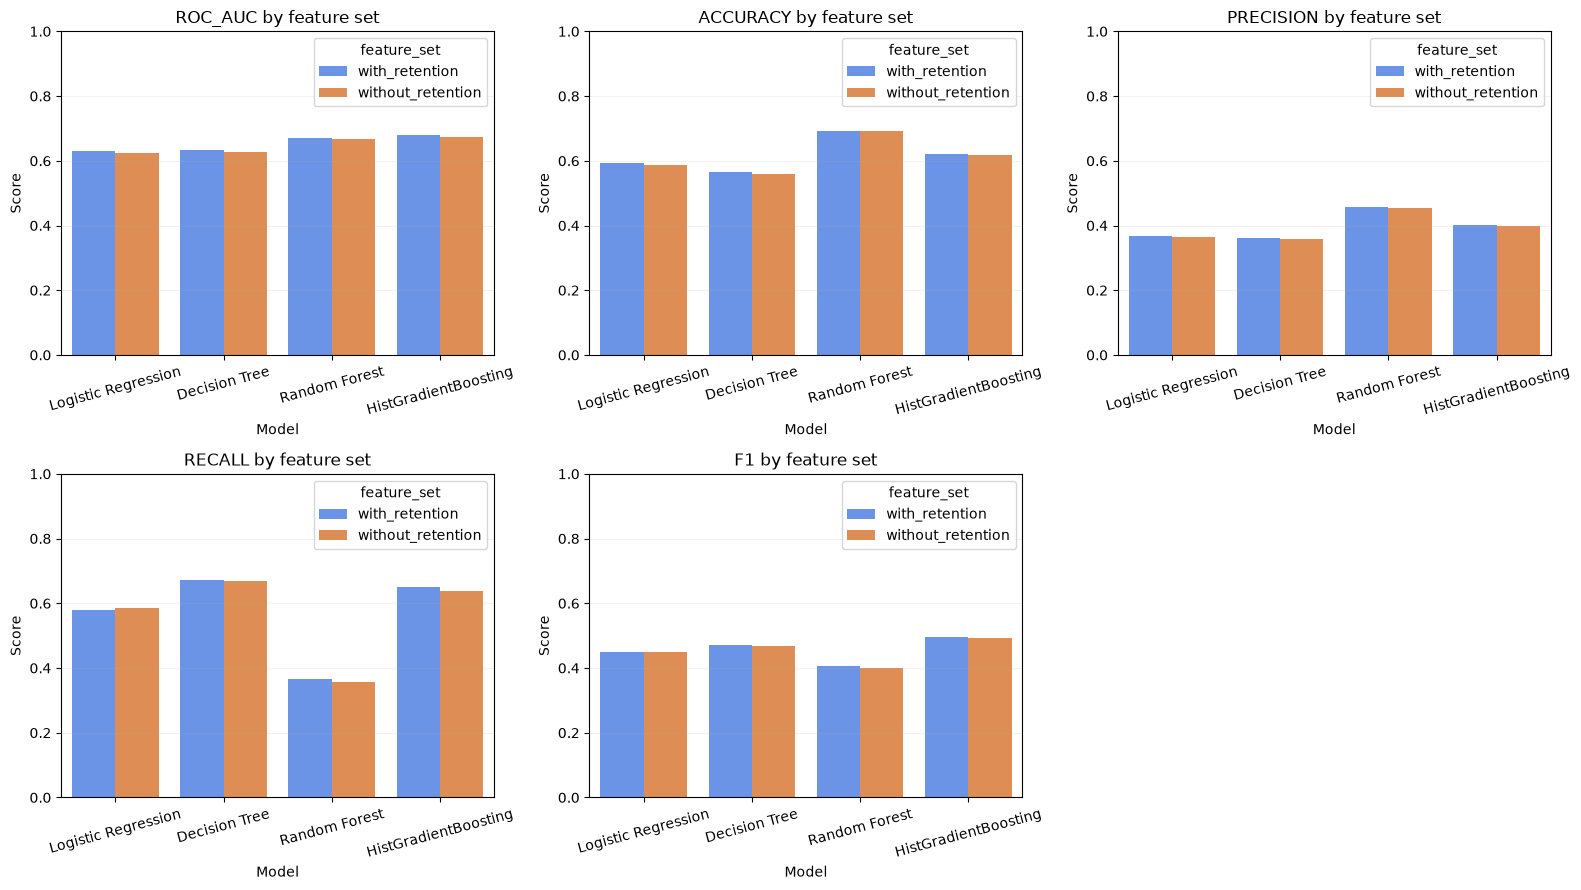

그래프 저장: C:\SKN_AI\skn-2nd-project-churnpred\artifacts\modeling\presentation_00_retention_model_comparison.png


In [10]:
# 10. 모델 핵심 성능 비교 시각화
plot_data = results.melt(
    id_vars=["feature_set", "model"],
    value_vars=["roc_auc", "accuracy", "precision", "recall", "f1"],
    var_name="metric",
    value_name="score",
)

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
for axis, metric in zip(axes.ravel(), ["roc_auc", "accuracy", "precision", "recall", "f1"]):
    subset = plot_data[plot_data["metric"] == metric]
    sns.barplot(data=subset, x="model", y="score", hue="feature_set", ax=axis)
    axis.set_title(metric.upper() + " by feature set")
    axis.set_xlabel("Model")
    axis.set_ylabel("Score")
    axis.set_ylim(0, 1)
    axis.tick_params(axis="x", rotation=15)
    axis.grid(axis="y", alpha=0.25)

axes[1, 2].axis("off")
plt.tight_layout()
figure_path = OUTPUT_DIR / "presentation_00_retention_model_comparison.png"
plt.savefig(figure_path, dpi=160, bbox_inches="tight")
plt.show()
print("그래프 저장:", figure_path)

In [11]:
# 11. 최종 모델 선정 결과
best_with = results_with.loc[results_with["roc_auc"].idxmax()]
best_without = results_without.loc[results_without["roc_auc"].idxmax()]

print("[Retention 포함 최적 모델]")
print(f"모델: {best_with['model']}")
print(f"ROC-AUC: {best_with['roc_auc']:.4f} | Accuracy: {best_with['accuracy']:.4f} | Recall: {best_with['recall']:.4f} | F1: {best_with['f1']:.4f}")
print("\n[Retention 제외 최적 모델]")
print(f"모델: {best_without['model']}")
print(f"ROC-AUC: {best_without['roc_auc']:.4f} | Accuracy: {best_without['accuracy']:.4f} | Recall: {best_without['recall']:.4f} | F1: {best_without['f1']:.4f}")

[Retention 포함 최적 모델]
모델: HistGradientBoosting
ROC-AUC: 0.6787 | Accuracy: 0.6206 | Recall: 0.6492 | F1: 0.4965

[Retention 제외 최적 모델]
모델: HistGradientBoosting
ROC-AUC: 0.6738 | Accuracy: 0.6193 | Recall: 0.6390 | F1: 0.4917


## 발표용 핵심 시각화

1. **핵심 성능 비교**: ROC-AUC, Recall, F1-score만 크게 비교한다.
2. **ROC Curve**: Retention 포함·제외 최종 모델의 이탈 고객 구분 성능을 비교한다.
3. **Confusion Matrix**: 실제 이탈 고객을 몇 명 찾았고 몇 명 놓쳤는지 보여준다.
4. **Feature Importance Top 10**: 최종 모델이 이탈 예측에 활용한 핵심 변수를 제시한다.

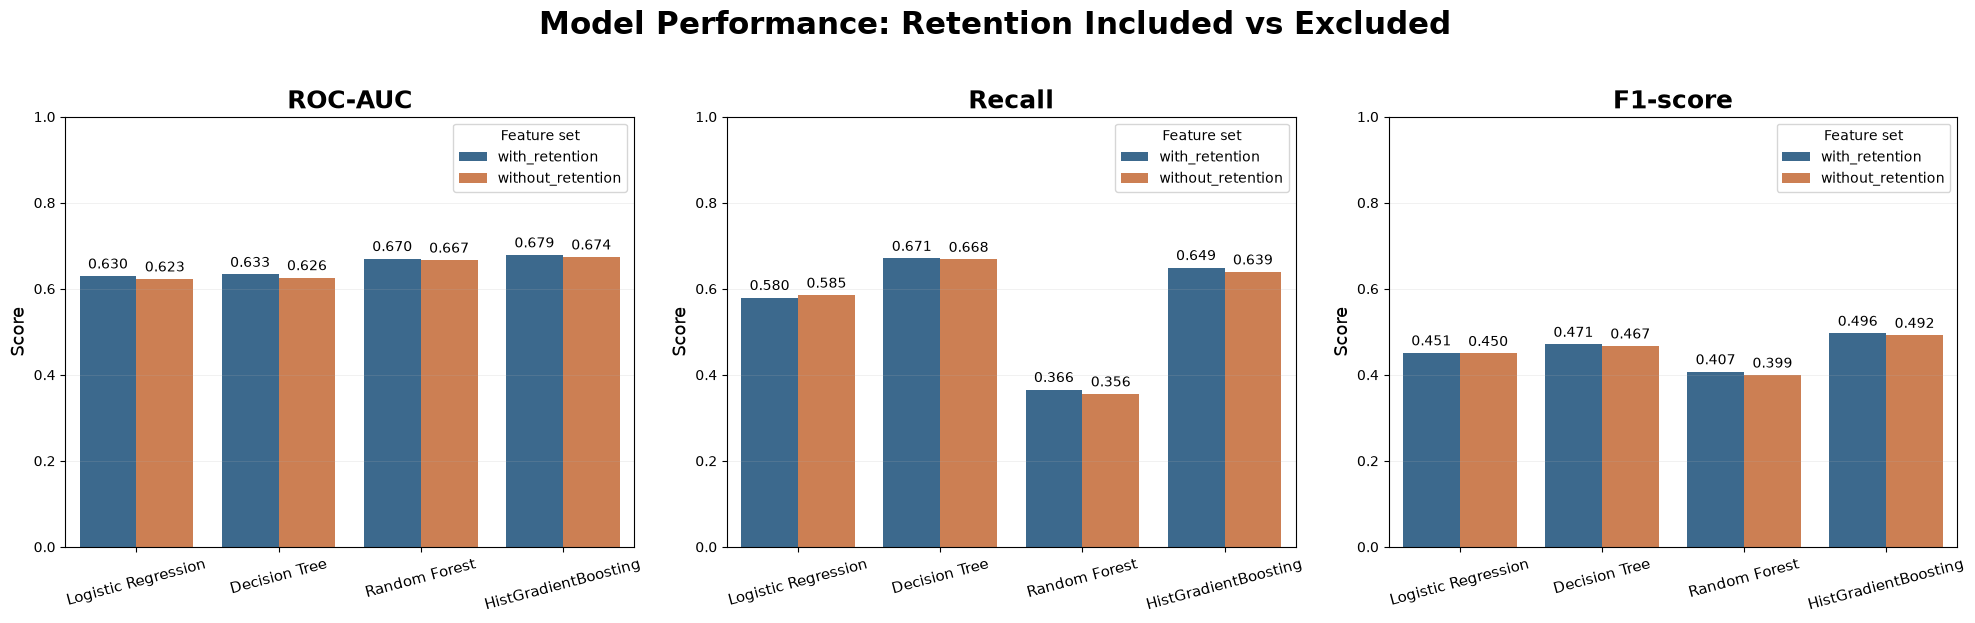

저장 완료: C:\SKN_AI\skn-2nd-project-churnpred\artifacts\modeling\presentation_01_model_performance.png


In [12]:
# 12. ① 핵심 성능 비교 그래프
presentation_metrics = results.melt(
    id_vars=["feature_set", "model"],
    value_vars=["roc_auc", "recall", "f1"],
    var_name="metric",
    value_name="score",
)

metric_titles = {
    "roc_auc": "ROC-AUC",
    "recall": "Recall",
    "f1": "F1-score",
}

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
for axis, metric in zip(axes, ["roc_auc", "recall", "f1"]):
    subset = presentation_metrics[presentation_metrics["metric"] == metric]
    sns.barplot(
        data=subset,
        x="model",
        y="score",
        hue="feature_set",
        palette=["#2F6B9A", "#E07A3F"],
        ax=axis,
    )
    axis.set_title(metric_titles[metric], fontsize=18, weight="bold")
    axis.set_xlabel("")
    axis.set_ylabel("Score", fontsize=13)
    axis.set_ylim(0, 1)
    axis.tick_params(axis="x", labelrotation=15, labelsize=11)
    axis.grid(axis="y", alpha=0.25)
    axis.legend(title="Feature set", fontsize=10)

    for container in axis.containers:
        axis.bar_label(container, fmt="%.3f", padding=3, fontsize=10)

fig.suptitle("Model Performance: Retention Included vs Excluded", fontsize=22, weight="bold", y=1.03)
plt.tight_layout()
path_performance = OUTPUT_DIR / "presentation_01_model_performance.png"
plt.savefig(path_performance, dpi=220, bbox_inches="tight")
plt.show()
print("저장 완료:", path_performance)

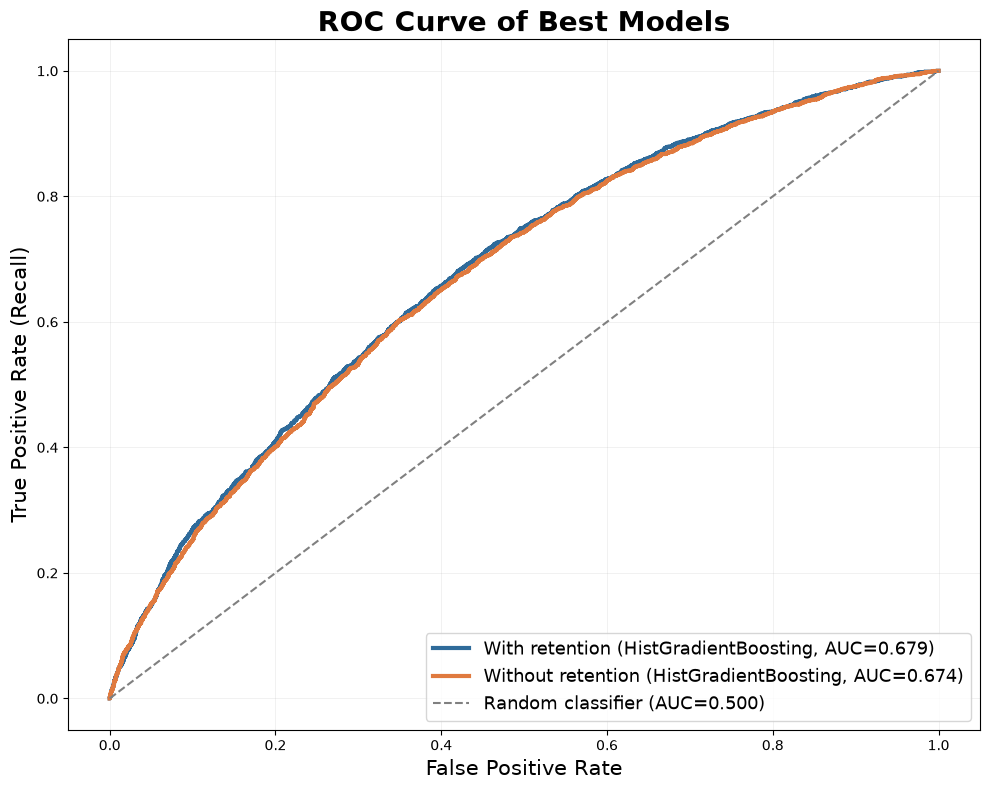

저장 완료: C:\SKN_AI\skn-2nd-project-churnpred\artifacts\modeling\presentation_02_roc_curve.png


In [13]:
# 13. ② Retention 포함·제외 최종 모델의 ROC Curve
model_with = fitted_with[best_with["model"]]
model_without = fitted_without[best_without["model"]]

probability_with = model_with.predict_proba(X_val_with)[:, 1]
probability_without = model_without.predict_proba(X_val_without)[:, 1]

fpr_with, tpr_with, _ = roc_curve(y_val_with, probability_with)
fpr_without, tpr_without, _ = roc_curve(y_val_without, probability_without)

fig, axis = plt.subplots(figsize=(10, 8))
axis.plot(
    fpr_with,
    tpr_with,
    linewidth=3,
    color="#2F6B9A",
    label=f"With retention ({best_with['model']}, AUC={best_with['roc_auc']:.3f})",
)
axis.plot(
    fpr_without,
    tpr_without,
    linewidth=3,
    color="#E07A3F",
    label=f"Without retention ({best_without['model']}, AUC={best_without['roc_auc']:.3f})",
)
axis.plot([0, 1], [0, 1], "--", color="gray", label="Random classifier (AUC=0.500)")
axis.set_title("ROC Curve of Best Models", fontsize=20, weight="bold")
axis.set_xlabel("False Positive Rate", fontsize=15)
axis.set_ylabel("True Positive Rate (Recall)", fontsize=15)
axis.legend(loc="lower right", fontsize=13)
axis.grid(alpha=0.25)
plt.tight_layout()
path_roc = OUTPUT_DIR / "presentation_02_roc_curve.png"
plt.savefig(path_roc, dpi=220, bbox_inches="tight")
plt.show()
print("저장 완료:", path_roc)

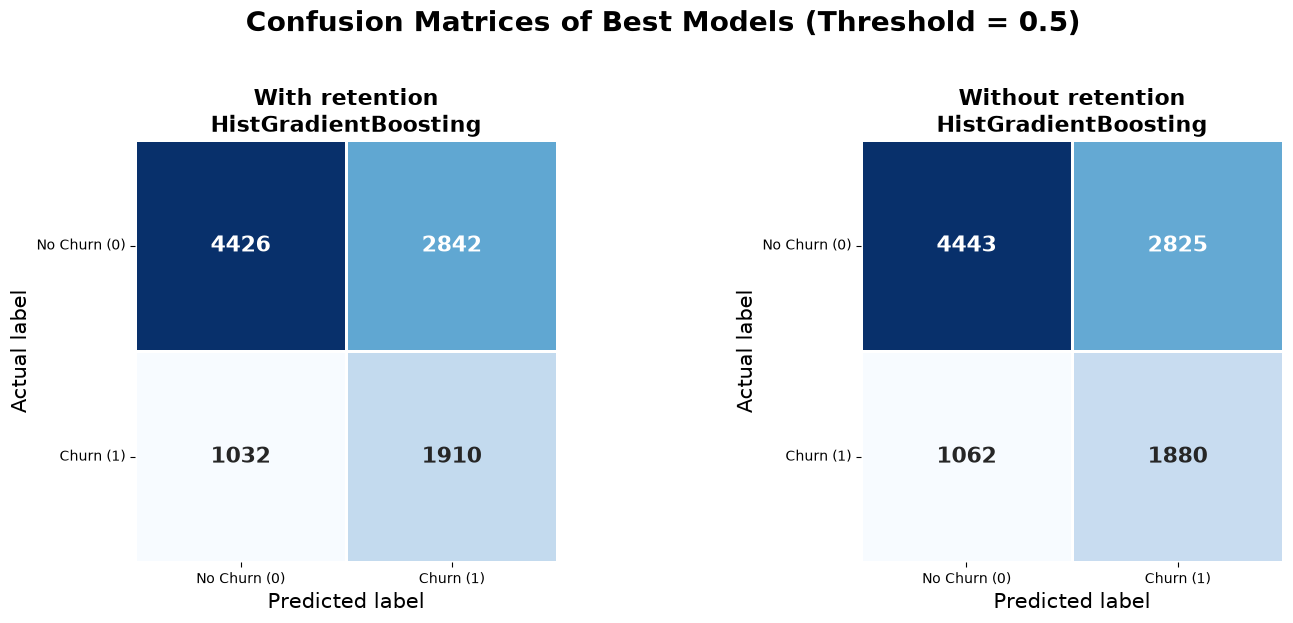

저장 완료: C:\SKN_AI\skn-2nd-project-churnpred\artifacts\modeling\presentation_03_confusion_matrix.png


In [14]:
# 14. ③ 최종 모델의 예측 결과: 혼동행렬
prediction_with = (probability_with >= 0.5).astype(int)
prediction_without = (probability_without >= 0.5).astype(int)

confusion_matrices = [
    (y_val_with, prediction_with, "With retention", best_with),
    (y_val_without, prediction_without, "Without retention", best_without),
]

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
for axis, (actual, predicted, feature_label, best_result) in zip(axes, confusion_matrices):
    matrix = confusion_matrix(actual, predicted, labels=[0, 1])
    sns.heatmap(
        matrix,
        annot=True,
        fmt="d",
        cmap="Blues",
        cbar=False,
        square=True,
        linewidths=1,
        linecolor="white",
        ax=axis,
        annot_kws={"size": 16, "weight": "bold"},
    )
    axis.set_title(
        f"{feature_label}\n{best_result['model']}",
        fontsize=16,
        weight="bold",
    )
    axis.set_xlabel("Predicted label", fontsize=15)
    axis.set_ylabel("Actual label", fontsize=15)
    axis.set_xticklabels(["No Churn (0)", "Churn (1)"], rotation=0)
    axis.set_yticklabels(["No Churn (0)", "Churn (1)"], rotation=0)

fig.suptitle("Confusion Matrices of Best Models (Threshold = 0.5)", fontsize=20, weight="bold", y=1.03)
plt.tight_layout()
path_confusion = OUTPUT_DIR / "presentation_03_confusion_matrix.png"
plt.savefig(path_confusion, dpi=220, bbox_inches="tight")
plt.show()
print("저장 완료:", path_confusion)

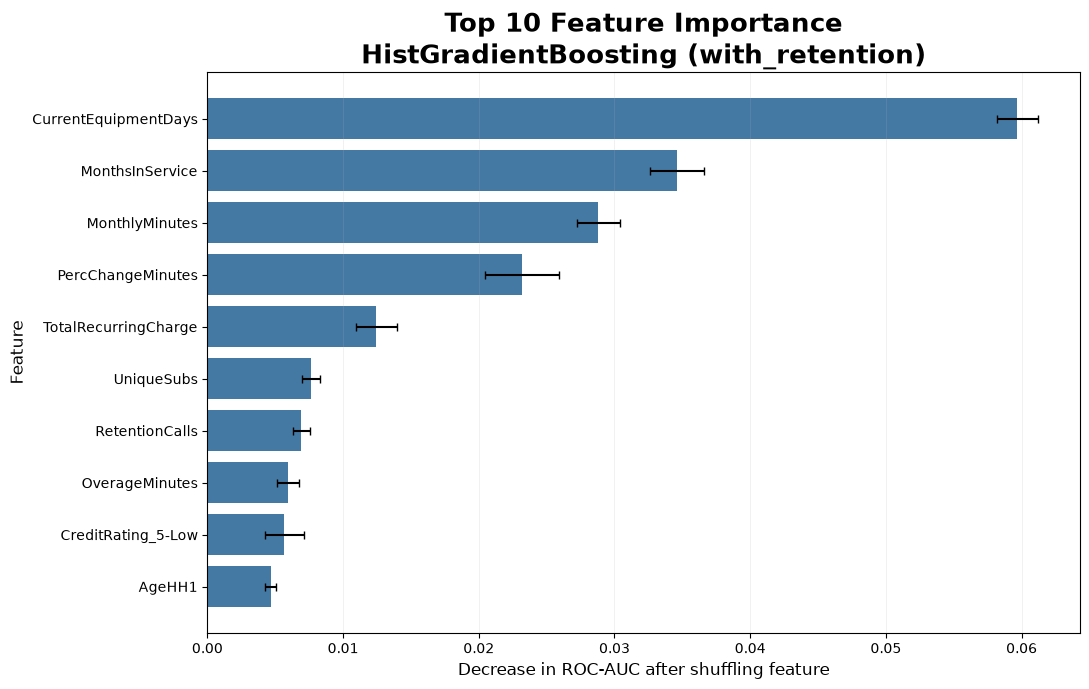

,feature,importance_mean,importance_std
26,CurrentEquipmentDays,0.0597,0.0015
21,MonthsInService,0.0346,0.0020
1,MonthlyMinutes,0.0288,0.0016
6,PercChangeMinutes,0.0232,0.0027
2,TotalRecurringCharge,0.0124,0.0015
22,UniqueSubs,0.0076,0.0007
31,RetentionCalls,0.0069,0.0006
4,OverageMinutes,0.0059,0.0008
69,CreditRating_5-Low,0.0057,0.0014
33,AgeHH1,0.0047,0.0004


저장 완료: C:\SKN_AI\skn-2nd-project-churnpred\artifacts\modeling\presentation_04_feature_importance.png


In [15]:
# 15. ④ 전체 최적 모델의 Feature Importance Top 10
# permutation importance: 한 변수를 섞었을 때 ROC-AUC가 얼마나 감소하는지로 중요도를 계산한다.
best_overall = results.sort_values("roc_auc", ascending=False).iloc[0]

if best_overall["feature_set"] == "with_retention":
    selected_model = fitted_with[best_overall["model"]]
    X_importance, y_importance = X_val_with, y_val_with
else:
    selected_model = fitted_without[best_overall["model"]]
    X_importance, y_importance = X_val_without, y_val_without

permutation_result = permutation_importance(
    selected_model,
    X_importance,
    y_importance,
    scoring="roc_auc",
    n_repeats=3,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

importance_df = pd.DataFrame({
    "feature": X_importance.columns,
    "importance_mean": permutation_result.importances_mean,
    "importance_std": permutation_result.importances_std,
}).sort_values("importance_mean", ascending=False)

top_10_importance = importance_df.head(10).sort_values("importance_mean")

fig, axis = plt.subplots(figsize=(11, 7))
axis.barh(
    top_10_importance["feature"],
    top_10_importance["importance_mean"],
    xerr=top_10_importance["importance_std"],
    color="#2F6B9A",
    alpha=0.9,
    capsize=3,
)
axis.set_title(
    f"Top 10 Feature Importance\n{best_overall['model']} ({best_overall['feature_set']})",
    fontsize=19,
    weight="bold",
)
axis.set_xlabel("Decrease in ROC-AUC after shuffling feature", fontsize=12)
axis.set_ylabel("Feature", fontsize=12)
axis.grid(axis="x", alpha=0.25)
plt.tight_layout()
path_importance = OUTPUT_DIR / "presentation_04_feature_importance.png"
plt.savefig(path_importance, dpi=220, bbox_inches="tight")
plt.show()

display(importance_df.head(10).round(4))
print("저장 완료:", path_importance)

## 기준선(Threshold) 조정 실험

현재 혼동행렬은 이탈 확률이 0.5 이상이면 이탈이라고 판단한 결과다.

기준선을 낮추면 더 많은 고객을 이탈 위험군으로 분류해 Recall은 높아지지만, 실제 유지 고객에게도 불필요한 접촉을 할 가능성이 커진다.

기준선을 높이면 접촉 대상은 줄지만 실제 이탈 고객을 더 많이 놓칠 수 있다.

,threshold,accuracy,precision,recall,f1,predicted_churn_customers,true_positive,false_positive,false_negative
0,0.3,0.4032,0.3188,0.9422,0.4764,8695,2772,5923,170
1,0.4,0.5145,0.3550,0.8382,0.4987,6947,2466,4481,476
2,0.5,0.6206,0.4019,0.6492,0.4965,4752,1910,2842,1032
3,0.6,0.7059,0.4847,0.3277,0.3910,1989,964,1025,1978
4,0.7,0.7185,0.5904,0.0755,0.1338,376,222,154,2720


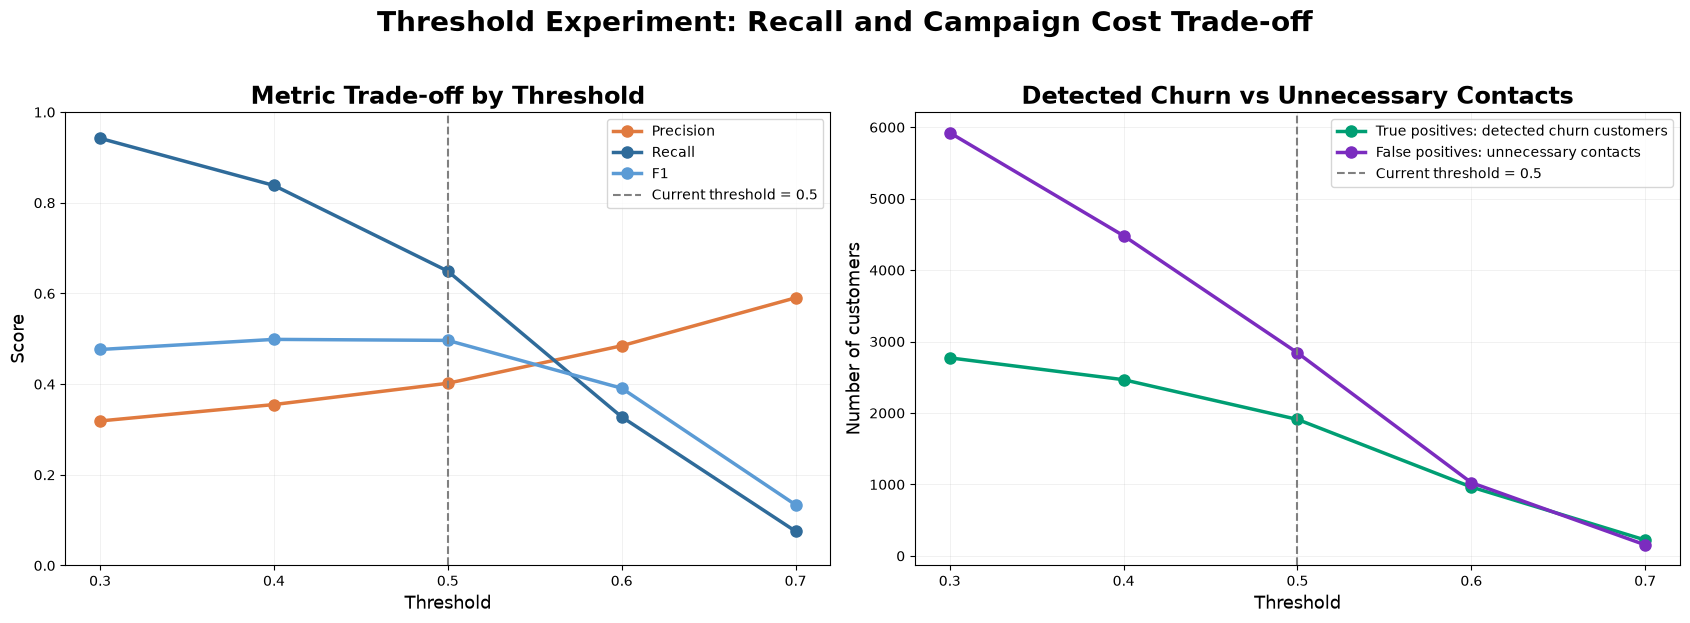

저장 완료: C:\SKN_AI\skn-2nd-project-churnpred\artifacts\modeling\presentation_05_threshold_tradeoff.png


In [19]:
# 16. ⑤ 기준선(Threshold)별 이탈 탐지·오탐의 균형 비교
# 전체 ROC-AUC가 가장 높은 Retention 포함 최종 모델을 기준으로 실험한다.
thresholds = [0.3, 0.4, 0.5, 0.6, 0.7]
threshold_rows = []

for threshold in thresholds:
    threshold_prediction = (probability_with >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_val_with, threshold_prediction, labels=[0, 1]).ravel()
    threshold_rows.append({
        "threshold": threshold,
        "accuracy": accuracy_score(y_val_with, threshold_prediction),
        "precision": precision_score(y_val_with, threshold_prediction, zero_division=0),
        "recall": recall_score(y_val_with, threshold_prediction, zero_division=0),
        "f1": f1_score(y_val_with, threshold_prediction, zero_division=0),
        "predicted_churn_customers": int(threshold_prediction.sum()),
        "true_positive": int(tp),
        "false_positive": int(fp),
        "false_negative": int(fn),
    })

threshold_results = pd.DataFrame(threshold_rows)
display(threshold_results.round(4))

fig, axes = plt.subplots(1, 2, figsize=(17, 6))

# 왼쪽: 평가 지표의 변화
for metric, color in [("precision", "#E07A3F"), ("recall", "#2F6B9A"), ("f1", "#5B9BD5")]:
    axes[0].plot(
        threshold_results["threshold"],
        threshold_results[metric],
        marker="o",
        linewidth=2.5,
        markersize=8,
        label=metric.capitalize(),
        color=color,
    )
axes[0].axvline(0.5, linestyle="--", color="gray", label="Current threshold = 0.5")
axes[0].set_title("Metric Trade-off by Threshold", fontsize=17, weight="bold")
axes[0].set_xlabel("Threshold", fontsize=13)
axes[0].set_ylabel("Score", fontsize=13)
axes[0].set_xticks(thresholds)
axes[0].set_ylim(0, 1)
axes[0].grid(alpha=0.25)
axes[0].legend()

# 오른쪽: 실제 이탈 탐지 수와 오탐 수의 변화
axes[1].plot(
    threshold_results["threshold"],
    threshold_results["true_positive"],
    marker="o",
    linewidth=2.5,
    markersize=8,
    label="True positives: detected churn customers",
    color="#009E73",
)
axes[1].plot(
    threshold_results["threshold"],
    threshold_results["false_positive"],
    marker="o",
    linewidth=2.5,
    markersize=8,
    label="False positives: unnecessary contacts",
    color="#7B2CBF",
)
axes[1].axvline(0.5, linestyle="--", color="gray", label="Current threshold = 0.5")
axes[1].set_title("Detected Churn vs Unnecessary Contacts", fontsize=17, weight="bold")
axes[1].set_xlabel("Threshold", fontsize=13)
axes[1].set_ylabel("Number of customers", fontsize=13)
axes[1].set_xticks(thresholds)
axes[1].grid(alpha=0.25)
axes[1].legend(fontsize=10)

fig.suptitle("Threshold Experiment: Recall and Campaign Cost Trade-off", fontsize=20, weight="bold", y=1.03)
plt.tight_layout()
threshold_figure_path = OUTPUT_DIR / "presentation_05_threshold_tradeoff.png"
plt.savefig(threshold_figure_path, dpi=220, bbox_inches="tight")
plt.show()
print("저장 완료:", threshold_figure_path)

## 최종 모델 및 상세 리포트 저장

- `models` 폴더에는 학습이 끝난 전체 파이프라인(결측치 처리·스케일링·분류 모델)을 `.joblib` 파일로 저장한다.
- `reports/modeling_report.md`에는 프로젝트 제출용 상세 모델링 리포트를 저장한다.
- Retention 포함·제외 모델은 사용 시점이 다르므로 두 파일을 각각 저장한다.

In [23]:
# 17. 최종 모델(joblib)과 상세 모델링 리포트(Markdown) 저장
MODELS_DIR = PROJECT_ROOT / "models"
REPORTS_DIR = PROJECT_ROOT / "reports"
MODELS_DIR.mkdir(parents=True, exist_ok=True)
REPORTS_DIR.mkdir(parents=True, exist_ok=True)

def make_file_stem(model_name, feature_set):
    """파일명에 사용할 안전한 모델 이름을 만든다."""
    safe_model_name = "".join(
        character.lower() if character.isalnum() else "_"
        for character in model_name
    ).strip("_")
    return f"{safe_model_name}_{feature_set}"

# Pipeline 전체를 저장한다.
# 따라서 나중에 불러올 때도 결측치 처리와 스케일링을 별도로 다시 할 필요가 없다.
best_with_model = fitted_with[best_with["model"]]
best_without_model = fitted_without[best_without["model"]]

with_model_path = MODELS_DIR / f"{make_file_stem(best_with['model'], 'with_retention')}.joblib"
without_model_path = MODELS_DIR / f"{make_file_stem(best_without['model'], 'without_retention')}.joblib"

joblib.dump(best_with_model, with_model_path)
joblib.dump(best_without_model, without_model_path)

# 보고서에서 사용할 표와 수치를 준비한다.
metric_columns = ["model", "feature_set", "roc_auc", "accuracy", "precision", "recall", "f1"]
report_metrics = results[metric_columns].sort_values(
    ["feature_set", "roc_auc"], ascending=[True, False]
).copy()
report_metrics["feature_set"] = report_metrics["feature_set"].map({
    "with_retention": "Retention 포함",
    "without_retention": "Retention 제외",
})

def markdown_table(dataframe, numeric_columns):
    header = "| " + " | ".join(dataframe.columns) + " |"
    divider = "| " + " | ".join(["---"] * len(dataframe.columns)) + " |"
    body = []
    for _, row in dataframe.iterrows():
        values = []
        for column in dataframe.columns:
            value = row[column]
            if column in numeric_columns:
                values.append(f"{value:.4f}")
            else:
                values.append(str(value))
        body.append("| " + " | ".join(values) + " |")
    return "\n".join([header, divider, *body])

metrics_table = markdown_table(
    report_metrics,
    numeric_columns=["roc_auc", "accuracy", "precision", "recall", "f1"],
)

with_matrix = confusion_matrix(y_val_with, prediction_with, labels=[0, 1])
without_matrix = confusion_matrix(y_val_without, prediction_without, labels=[0, 1])

feature_name_korean = {
    "CurrentEquipmentDays": "현재 단말기 사용 일수",
    "MonthsInService": "서비스 이용 개월 수",
    "MonthlyMinutes": "월 통화 시간",
    "PercChangeMinutes": "통화 시간 변화",
    "TotalRecurringCharge": "월 정기 요금",
    "UniqueSubs": "전체 가입 회선 수",
    "RetentionCalls": "이탈 방어 연락 횟수",
    "OverageMinutes": "초과 사용 통화 시간",
    "CreditRating_5-Low": "신용등급 5-낮음 여부",
    "AgeHH1": "가구원 1 나이",
}

importance_lines = []
for rank, (_, row) in enumerate(importance_df.head(10).iterrows(), start=1):
    korean_name = feature_name_korean.get(row["feature"], row["feature"])
    importance_lines.append(
        f"{rank}. `{row['feature']}` ({korean_name}): {row['importance_mean']:.4f}"
    )
importance_text = "\n".join(importance_lines)

threshold_report_columns = [
    "threshold", "accuracy", "precision", "recall", "f1",
    "predicted_churn_customers", "true_positive", "false_positive", "false_negative",
]
threshold_table_markdown = markdown_table(
    threshold_results[threshold_report_columns],
    numeric_columns=["threshold", "accuracy", "precision", "recall", "f1"],
)
accuracy_interpretation = (
    f"최종 Retention 포함 모델의 Accuracy는 {best_with['accuracy']:.1%}이다. "
    "이는 이탈 고객을 최대한 놓치지 않도록 클래스 가중치를 적용하고, 기준선 0.5에서 Recall을 우선했기 때문에 "
    "일부 유지 고객도 이탈 위험군으로 분류한 결과이다."
)

auc_gain = best_with["roc_auc"] - best_without["roc_auc"]
recall_gain_count = int(with_matrix[1, 1] - without_matrix[1, 1])
false_positive_gain = int(with_matrix[0, 1] - without_matrix[0, 1])

report = f"""# 고객 이탈 예측 모델링 상세 리포트

## 1. 프로젝트 목적

고객의 통화·요금·단말기·인구통계 정보를 활용해 고객 이탈 여부(`Churn`)를 예측한다.
특히 이탈 방어 활동(Retention) 정보를 포함했을 때와 제외했을 때의 성능 차이를 비교했다.

## 2. 데이터 및 실험 설계

| 구분 | Retention 포함 | Retention 제외 |
| --- | ---: | ---: |
| 학습 데이터 수 | {len(X_train_with):,} | {len(X_train_without):,} |
| 검증 데이터 수 | {len(X_val_with):,} | {len(X_val_without):,} |
| 입력 피처 수 | {X_train_with.shape[1]:,} | {X_train_without.shape[1]:,} |
| 타깃 변수 | Churn (1=이탈, 0=유지) | Churn (1=이탈, 0=유지) |

- 학습에는 `train_with_retention.csv`, `train_without_retention.csv`만 사용했다.
- 검증에는 `val_with_retention.csv`, `val_without_retention.csv`만 사용했다.
- Retention 포함 버전에는 `RetentionCalls`, `RetentionOffersAccepted`, 유지팀 연락 여부 관련 변수가 추가된다.
- test 데이터는 최종 모델을 확정한 후 최종 예측에만 사용한다.

## 3. 비교 모델과 평가 기준

비교 모델은 Logistic Regression, Decision Tree, Random Forest, HistGradientBoosting이다.

- 주 평가 지표는 **ROC-AUC**다. 여러 임계값에서 이탈 고객을 유지 고객보다 높은 위험도로 구분하는 능력을 본다.
- Accuracy는 전체 정답 비율이다.
- Precision은 이탈이라고 예측한 고객 중 실제 이탈 고객의 비율이다.
- Recall은 실제 이탈 고객 중 모델이 찾아낸 비율이다.
- F1-score는 Precision과 Recall의 균형을 나타낸다.

## 4. 전체 검증 성능 비교

{metrics_table}

## 5. 최종 모델 선정 결과

### 5-1. Retention 포함 모델

- 최종 모델: **{best_with['model']}**
- ROC-AUC: **{best_with['roc_auc']:.4f}**
- Accuracy: {best_with['accuracy']:.4f}
- Precision: {best_with['precision']:.4f}
- Recall: {best_with['recall']:.4f}
- F1-score: **{best_with['f1']:.4f}**
- 저장 파일: `models/{with_model_path.name}`

### 5-2. Retention 제외 모델

- 최종 모델: **{best_without['model']}**
- ROC-AUC: **{best_without['roc_auc']:.4f}**
- Accuracy: {best_without['accuracy']:.4f}
- Precision: {best_without['precision']:.4f}
- Recall: {best_without['recall']:.4f}
- F1-score: **{best_without['f1']:.4f}**
- 저장 파일: `models/{without_model_path.name}`

### 5-3. Retention 변수의 효과

- Retention 포함 모델의 ROC-AUC는 제외 모델보다 **{auc_gain:.4f}** 높다.
- 임계값 0.5 기준으로, Retention 포함 모델은 실제 이탈 고객을 **{recall_gain_count:,}명 더 탐지**했다.
- 반면 유지 고객을 이탈로 잘못 예측한 고객도 **{false_positive_gain:,}명 더 많다.**

따라서 유지팀의 접촉 비용과 이탈 고객을 놓쳤을 때의 비용을 함께 고려해 운영 임계값을 조정할 수 있다.

## 6. Accuracy와 기준선 0.5 해석

> {accuracy_interpretation}

현재 기준선 0.5는 이탈 확률이 50% 이상인 고객을 이탈 위험군으로 분류한다. 아래는 기준선을 바꾸었을 때의 검증 성능과 고객 접촉 규모 변화다.

{threshold_table_markdown}

- 기준선을 낮추면 실제 이탈 고객을 더 많이 탐지할 수 있지만, 유지 고객에게도 더 많은 방어 활동을 하게 된다.
- 기준선을 높이면 접촉 대상과 오탐은 줄지만, 실제 이탈 고객을 더 많이 놓칠 수 있다.
- 최적 기준선은 캠페인 예산, 유지 연락 비용, 이탈 고객을 놓쳤을 때의 비용을 함께 고려해 결정한다.

## 7. 혼동행렬 해석

### Retention 포함 모델

| 실제값 / 예측값 | 유지(0) | 이탈(1) |
| --- | ---: | ---: |
| 유지(0) | {with_matrix[0, 0]:,} | {with_matrix[0, 1]:,} |
| 이탈(1) | {with_matrix[1, 0]:,} | {with_matrix[1, 1]:,} |

### Retention 제외 모델

| 실제값 / 예측값 | 유지(0) | 이탈(1) |
| --- | ---: | ---: |
| 유지(0) | {without_matrix[0, 0]:,} | {without_matrix[0, 1]:,} |
| 이탈(1) | {without_matrix[1, 0]:,} | {without_matrix[1, 1]:,} |

## 8. 전체 최적 모델의 주요 피처

순열 중요도(Permutation Importance) 기준 상위 10개 피처다. 변수를 무작위로 섞었을 때 ROC-AUC가 크게 떨어질수록 모델 예측에 중요한 정보라는 뜻이다.

{importance_text}

피처 중요도는 모델 예측에 유용한 정도를 뜻하며, 해당 변수가 이탈의 직접 원인임을 증명하지는 않는다.

## 9. 운영 제안

1. **사전 이탈 예방**: 유지팀 접촉 정보가 아직 없는 시점이라면 `Retention 제외 모델`을 사용한다.
2. **접촉 이력 반영 위험도 판단**: 유지 활동 정보까지 확보된 경우 `Retention 포함 모델`을 사용한다.
3. 단말기 사용 기간, 서비스 이용 기간, 통화 시간 변화가 큰 고객을 우선 관리 후보로 검토한다.
4. 임계값 0.5는 기본값이므로, 캠페인 예산과 고객 접촉 비용에 맞춰 Recall과 Precision의 균형을 조정한다.

## 10. 한계 및 유의사항

- Retention 변수는 이탈 판정 시점 이후에 기록된 정보라면 데이터 누수가 될 수 있으므로 측정 시점을 반드시 확인해야 한다.
- 최종 발표 전 교차검증 또는 test 데이터로 성능을 추가 확인하여 신뢰도를 높인다.
- 피처 중요도는 인과관계가 아니라 예측 기여도다.

## 11. 생성 산출물

- 모델: `models/{with_model_path.name}`
- 모델: `models/{without_model_path.name}`
- 상세 리포트: `reports/modeling_report.md`
- 모델 성능 비교: `artifacts/modeling/presentation_00_retention_model_comparison.png`
- 성능 그래프: `artifacts/modeling/presentation_01_model_performance.png`
- ROC 곡선: `artifacts/modeling/presentation_02_roc_curve.png`
- 혼동행렬: `artifacts/modeling/presentation_03_confusion_matrix.png`
- 피처 중요도: `artifacts/modeling/presentation_04_feature_importance.png`
- 기준선 비교: `artifacts/modeling/presentation_05_threshold_tradeoff.png`
"""

report_path = REPORTS_DIR / "modeling_report.md"
report_path.write_text(report, encoding="utf-8")

print("저장 완료")
print("- 모델:", with_model_path)
print("- 모델:", without_model_path)
print("- 상세 리포트:", report_path)


저장 완료
- 모델: C:\SKN_AI\skn-2nd-project-churnpred\models\histgradientboosting_with_retention.joblib
- 모델: C:\SKN_AI\skn-2nd-project-churnpred\models\histgradientboosting_without_retention.joblib
- 상세 리포트: C:\SKN_AI\skn-2nd-project-churnpred\reports\modeling_report.md


## 최종 해석 시 유의사항

1. Retention 포함 모델의 성능이 더 높더라도, 해당 변수가 **이탈 판정 시점 이전에 확보되는 정보인지** 확인해야 한다.
2. 사전 예방 목적이라면 `without_retention` 모델을 운영 모델로 제안한다.
3. 유지팀 접촉 이력까지 포함한 사후 위험도 산정 목적이라면 `with_retention` 모델을 사용할 수 있다.
4. 본 실험에서는 validation 세트를 한 번만 사용했으므로, 최종 발표에서는 교차검증 또는 별도 test 데이터로 성능을 한 번 더 확인하면 신뢰도를 높일 수 있다.